In [1]:
import os
import onnxruntime as ort
from onnxruntime import InferenceSession
from transformers import CLIPImageProcessor, CLIPTokenizer

In [2]:
destination = "clip_models"
clip_vision_path = os.path.join(destination, "onnx", "clip_vis_quant.onnx")
session_opts = ort.SessionOptions()
providers = ["CPUExecutionProvider"]

clip_vision_session = InferenceSession(
                clip_vision_path,
                session_opts,
                providers=providers
            )
processor = CLIPImageProcessor.from_pretrained(destination)
processor

CLIPImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

In [3]:
clip_text_path = os.path.join(destination, "onnx", "clip_text.onnx")

clip_text_session = InferenceSession(
                clip_text_path,
                session_opts,
                providers=providers
            )
tokenizer: CLIPTokenizer = CLIPTokenizer.from_pretrained(destination)
tokenizer

CLIPTokenizer(name_or_path='clip_models', vocab_size=49408, model_max_length=77, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

(3, 224, 224)


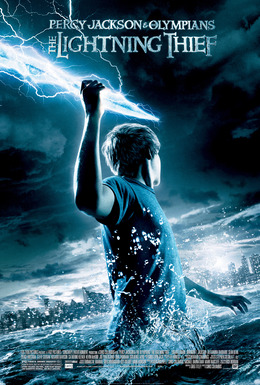

In [4]:
from PIL import Image

image = Image.open("./imgs/percy.jpg")
image_arr = processor(image)['pixel_values'][0]
print(image_arr.shape)
image

In [5]:
#text = ["lightning", "broomstick", "dragon", "dark angel"]
text = [
        "guy on the cover holding a lightning bolt about to throw it at some city",
        "JK Rowling's book about wizards",
        "some series about dragons with a big blue-eyed on on the cover",
        "a dark angel floating up to heaven, feathers falling off"
    ]
text_arr = tokenizer(text, return_tensors='np', padding="max_length")
text_arr.get('input_ids').shape

(4, 77)

In [6]:
import torch
import numpy as np

with torch.no_grad(), torch.autocast("cuda"):
    image_features = torch.as_tensor(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]))
    text_features = torch.as_tensor(np.asarray(clip_text_session.run(None, {"text": text_arr.get('input_ids')})[0]))
    image_features /= image_features.norm(dim=-1, keepdim=True)
    #text_features /= text_features.norm(dim=-1, keepdim=True)
    text_features /= torch.sqrt(text_features.square().sum())

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

text_probs.round(decimals=3)

tensor([[0.6690, 0.2750, 0.0240, 0.0320]])

In [7]:
text_features = torch.as_tensor(np.asarray(clip_text_session.run(None, {"text": text_arr.get('input_ids')})[0]))

In [8]:
text_features.norm(dim=-1, keepdim=True)

tensor([[6.8583],
        [8.3002],
        [7.9965],
        [7.1543]])

In [9]:
text_features.norm(keepdim=True)

tensor([[15.2006]])

In [10]:
torch.sqrt(text_features.square().sum())

tensor(15.2006)

In [11]:
image_features = torch.as_tensor(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]))

In [12]:
image_features.norm(dim=-1, keepdim=True)

tensor([[10.4880]])

In [13]:
torch.sqrt(image_features.square().sum())

tensor(10.4880)

In [14]:
np.linalg.norm(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]), axis=-1, keepdims=True)

array([[10.488024]], dtype=float32)

In [15]:
image_features.shape

torch.Size([1, 512])

In [16]:
text_features.shape

torch.Size([4, 512])

(3, 224, 224)


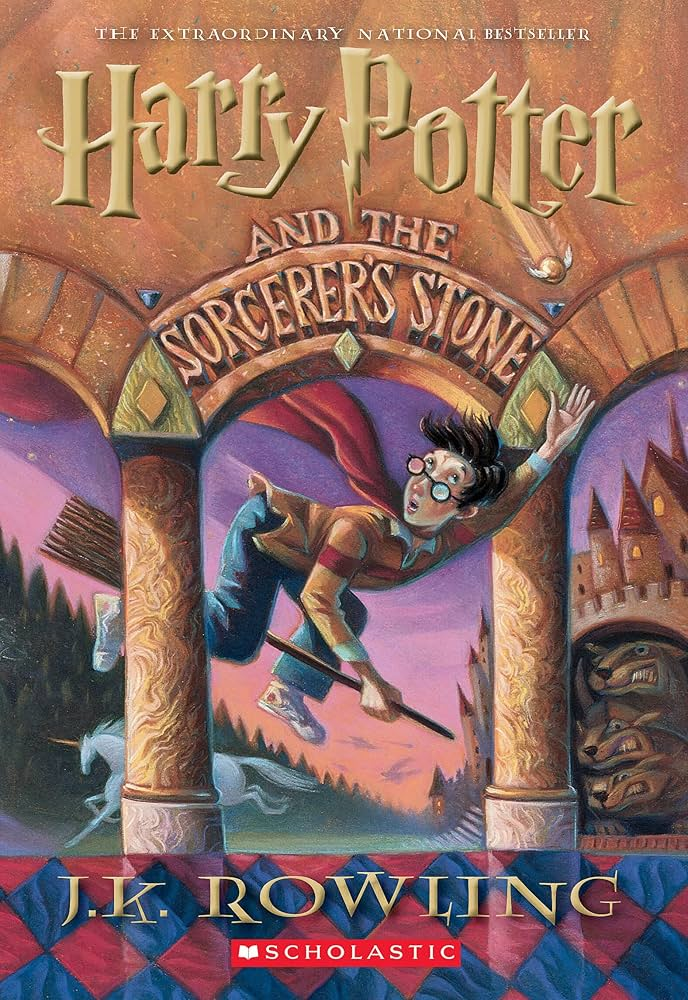

In [17]:
image = Image.open("./imgs/potter.jpg")
image_arr = processor(image)['pixel_values'][0]
print(image_arr.shape)
image

In [18]:
with torch.no_grad(), torch.autocast("cuda"):
    image_features = torch.as_tensor(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]))
    text_features = torch.as_tensor(np.asarray(clip_text_session.run(None, {"text": text_arr.get('input_ids')})[0]))
    image_features /= image_features.norm(dim=-1, keepdim=True)
    #text_features /= text_features.norm(dim=-1, keepdim=True)
    text_features /= torch.sqrt(text_features.square().sum())

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

text_probs.round(decimals=3)

tensor([[0.0050, 0.6450, 0.3500, 0.0000]])

(3, 224, 224)


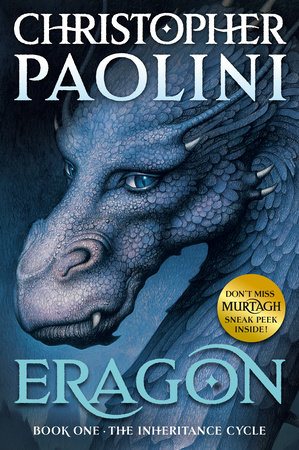

In [19]:
image = Image.open("./imgs/eragon.jpeg")
image_arr = processor(image)['pixel_values'][0]
print(image_arr.shape)
image

In [20]:
with torch.no_grad(), torch.autocast("cuda"):
    image_features = torch.as_tensor(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]))
    text_features = torch.as_tensor(np.asarray(clip_text_session.run(None, {"text": text_arr.get('input_ids')})[0]))
    image_features /= image_features.norm(dim=-1, keepdim=True)
    #text_features /= text_features.norm(dim=-1, keepdim=True)
    text_features /= torch.sqrt(text_features.square().sum())

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

text_probs.round(decimals=3)

tensor([[0., 0., 1., 0.]])

(3, 224, 224)


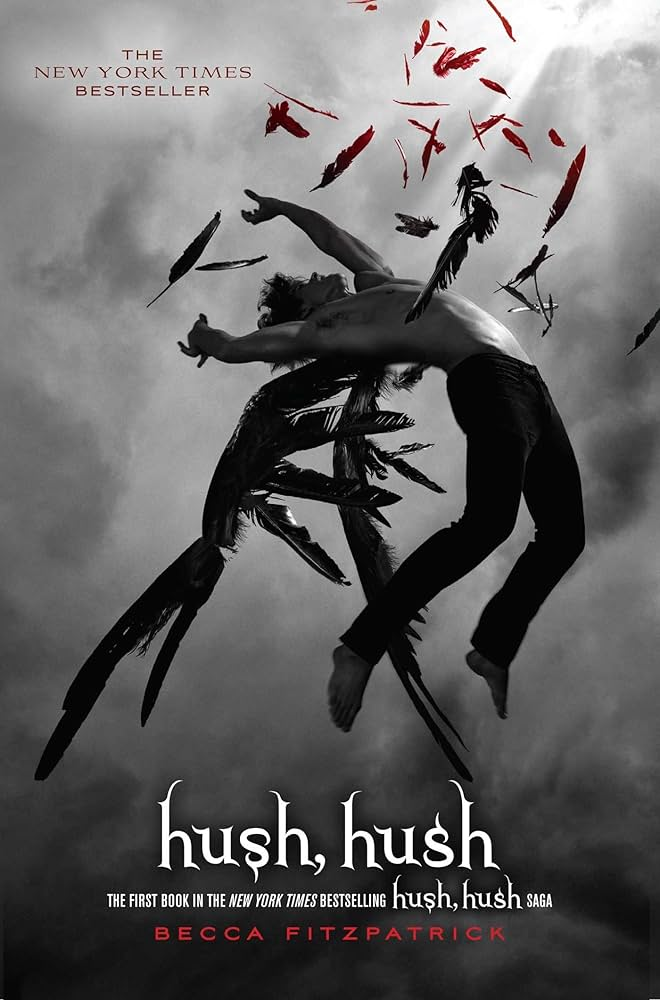

In [21]:
image = Image.open("./imgs/hush.jpg")
image_arr = processor(image)['pixel_values'][0]
print(image_arr.shape)
image

In [22]:
with torch.no_grad(), torch.autocast("cuda"):
    image_features = torch.as_tensor(np.asarray(clip_vision_session.run(None, {"images": [image_arr]})[0]))
    text_features = torch.as_tensor(np.asarray(clip_text_session.run(None, {"text": text_arr.get('input_ids')})[0]))
    image_features /= image_features.norm(dim=-1, keepdim=True)
    #text_features /= text_features.norm(dim=-1, keepdim=True)
    text_features /= torch.sqrt(text_features.square().sum())

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

text_probs.round(decimals=3)

tensor([[0.0090, 0.0850, 0.3180, 0.5880]])